# Feature Selection

## Package Imports

In [1]:
from pickle import dump, load
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Dataset Loading

In [2]:
with open('data/feature_eng/X_train.pkl', 'rb') as file:
    X_train = load(file)

with open('data/feature_eng/y_train.pkl', 'rb') as file:
    y_train = load(file)

with open('data/feature_eng/X_test.pkl', 'rb') as file:
    X_test = load(file)

with open('data/feature_eng/y_test.pkl', 'rb') as file:
    y_test = load(file)

print(f"Training data, row: {len(X_train)}")
display(X_train.head())
print(f"Test data, row: {len(X_test)}")
display(X_test.head())

Training data, row: 7219


,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary
1926,596,2.0,0.0,30,1,0.00,8125.39
1634,607,1.0,1.0,29,7,102609.00,163257.44
4742,694,1.0,1.0,37,1,95668.82,100335.55
8990,714,1.0,1.0,53,1,99141.86,72496.05
1297,769,0.0,1.0,29,8,0.00,172290.61


Test data, row: 2407


,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary
6071,848,1.0,0.0,40,5,148495.64,158853.98
4407,612,2.0,0.0,36,5,119799.27,159416.58
1098,604,0.0,1.0,28,7,0.00,58595.64
9524,499,0.0,1.0,60,7,76961.60,83643.87
5294,624,0.0,0.0,38,3,0.00,163666.85


## Feature Selection Strategy

Here, we simply focuses on correlation between numerical values. While it is possible to measure correlation between a pair of numerical variables, the selection here is simply a qualitative one.

Ccorrelation computation used here is Spearman in this notebook due to skewed data observed at EDA.


## Drawing Correlation Heatmap

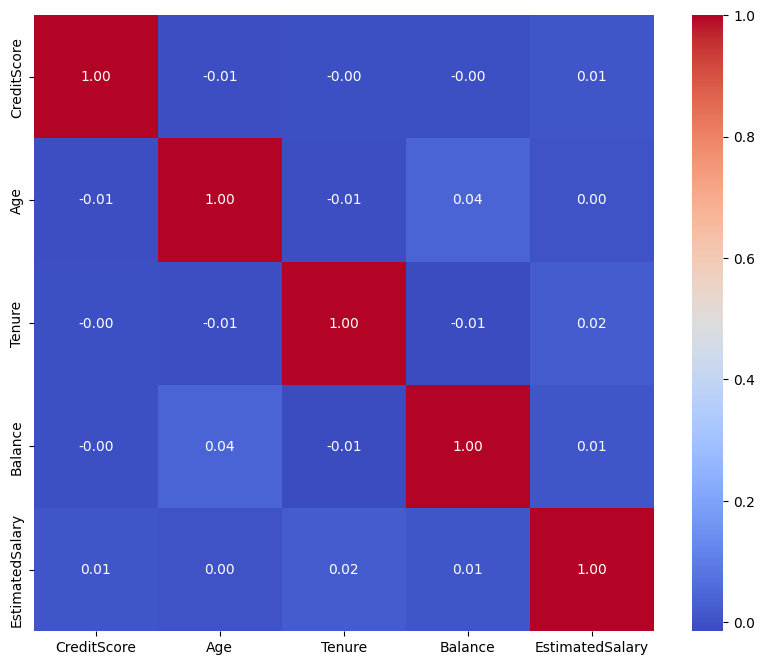

In [3]:
X_num = X_train[['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']]

corr_matrix = X_num.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.show()

Here we found that correlation coefficients are typically low, thus we consider to use all numerical features.

## Saving Data

In [4]:
if not os.path.exists('data/feature_sel'):
    os.makedirs('data/feature_sel')

with open('data/feature_sel/X_train.pkl', 'wb') as file:
    dump(X_train, file)

with open('data/feature_sel/y_train.pkl', 'wb') as file:
    dump(y_train, file)

with open('data/feature_sel/X_test.pkl', 'wb') as file:
    dump(X_test, file)

with open('data/feature_sel/y_test.pkl', 'wb') as file:
    dump(y_test, file)

